In [276]:
import higher
import numpy as np

import time
import torch
import torch.nn as nn
import torch.optim as optim

from typing import Tuple
import matplotlib.pyplot as plt

np.random.seed(7)


device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"


In [281]:
def generate_task1_data(batch_size=20,range_ : Tuple[int,int]=(-5,5)):
    
    np.random.seed(42)
    
    X = np.c_[np.random.uniform(*range_, (batch_size)),
              np.random.uniform(*range_, (batch_size)),
              np.random.uniform(*range_, (batch_size))]
    X_tensor = torch.from_numpy(X).float().to(device)
    # y_tensor = (X_tensor[:, 0] * torch.sin(X_tensor[:, 1] + X_tensor[:, 2])).unsqueeze(1).to(device)
    y_tensor = torch.sin(X_tensor[:,2]+torch.pi/2).unsqueeze(1).to(device)
    return X_tensor, y_tensor

def generate_task2_data(batch_size=20,range_ : Tuple[int,int]=(-5,5)):
    
    np.random.seed(42)
    
    X = np.c_[np.random.uniform(*range_, (batch_size)),
              np.random.uniform(*range_, (batch_size)),
              np.random.uniform(*range_, (batch_size))]
    
    X_tensor = torch.from_numpy(X).float().to(device)
    # y_tensor = (X_tensor[:, 0] * torch.sin(X_tensor[:, 1] + X_tensor[:, 2])).unsqueeze(1).to(device)
    y_tensor = torch.sin(X_tensor[:,2]-torch.pi/2).unsqueeze(1).to(device)
    return X_tensor, y_tensor

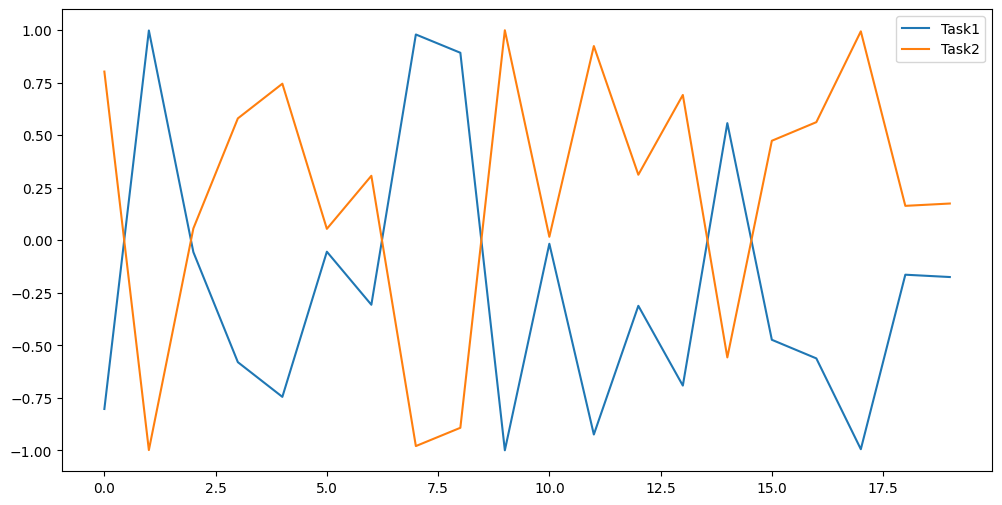

In [285]:
n = 20
_, temp_Y = generate_task1_data(n)
_, temp2_Y = generate_task2_data(n)


plt.figure(figsize=(12,6))
plt.plot(torch.arange(0,n),temp_Y.cpu(),label='Task1')
plt.plot(torch.arange(0,n),temp2_Y.cpu(),label='Task2')

plt.legend()
plt.show()

In [286]:
class SimpleRegressor(nn.Module):

    def __init__(self):
        super(SimpleRegressor,self).__init__()

        self.layers = nn.Sequential(nn.Linear(3,32),nn.BatchNorm1d(32),nn.ReLU())
        self.predictor = nn.Linear(32,1)


    def forward(self,x):
        return self.predictor(self.layers(x))


In [287]:
def train_maml(meta_model : object, meta_optimizer : object, loss_function :object, \
                num_meta_iterations : int, num_tasks_per_meta_iterations: int, inner_lr : float,\
                num_inner_loop_steps : int, train_data_generator : Tuple[torch.tensor,torch.tensor], grad_clip_norm : float = 1.0 ):
    
    print('MAML Training Started !')

    for iter in range(num_meta_iterations):

        start_time = time.time()
        
        meta_optimizer.zero_grad()
        meta_loss_sum = 0

        for _ in range(num_tasks_per_meta_iterations):

            X_in, Y_in = train_data_generator()
            X_out, Y_out = train_data_generator()

            with higher.innerloop_ctx(meta_model,meta_optimizer,copy_initial_weights=False) as (temp_model,temp_optimizer) :
                
                # inner loop
                for _ in range(num_inner_loop_steps):
                     
                    predictions = temp_model(X_in)
                    inner_loss = loss_function(predictions,Y_in)

                    temp_optimizer.step(inner_loss)
                
                # outer loop
                adapted_predictions = temp_model(X_out)
                outer_loss = loss_function(adapted_predictions,Y_out)
                meta_loss_sum  += outer_loss

        meta_loss_sum/=num_tasks_per_meta_iterations
        meta_loss_sum.backward()
        
        nn.utils.clip_grad_norm_(meta_model.parameters(), max_norm=grad_clip_norm)
        meta_optimizer.step()

        end_time = time.time()-start_time

        if iter%50==0:
            print(f"Iter [{iter}/{num_meta_iterations}] | Meta model train loss : {meta_loss_sum.item():.4f} | Time Taken : {end_time:.4f}")
    
    print('MAML Training Finished !')
        


In [288]:
INNER_LR = 0.001
META_LR = 0.0001
NUM_INNER_STEPS = 5
NUM_META_ITERATIONS = 1000
NUM_TASKS_PER_META_ITERATION = 8
GRAD_CLIP_NORM = 1.0 

meta_model = SimpleRegressor().to(device)
meta_optimizer = optim.Adam(meta_model.parameters(), lr=META_LR)
loss_function = nn.MSELoss()

train_maml(meta_model, meta_optimizer, loss_function,
            NUM_META_ITERATIONS, NUM_TASKS_PER_META_ITERATION,
            INNER_LR, NUM_INNER_STEPS,
            generate_task1_data, grad_clip_norm=GRAD_CLIP_NORM)


MAML Training Started !
Iter [0/1000] | Meta model train loss : 0.4538 | Time Taken : 0.1247
Iter [50/1000] | Meta model train loss : 0.3985 | Time Taken : 0.1324
Iter [100/1000] | Meta model train loss : 0.3521 | Time Taken : 0.1337
Iter [150/1000] | Meta model train loss : 0.3120 | Time Taken : 0.1345
Iter [200/1000] | Meta model train loss : 0.2800 | Time Taken : 0.1236
Iter [250/1000] | Meta model train loss : 0.2546 | Time Taken : 0.1269
Iter [300/1000] | Meta model train loss : 0.2340 | Time Taken : 0.1251
Iter [350/1000] | Meta model train loss : 0.2176 | Time Taken : 0.1357
Iter [400/1000] | Meta model train loss : 0.2041 | Time Taken : 0.1369
Iter [450/1000] | Meta model train loss : 0.1929 | Time Taken : 0.1378
Iter [500/1000] | Meta model train loss : 0.1835 | Time Taken : 0.1305
Iter [550/1000] | Meta model train loss : 0.1757 | Time Taken : 0.1357
Iter [600/1000] | Meta model train loss : 0.1690 | Time Taken : 0.1301
Iter [650/1000] | Meta model train loss : 0.1630 | Time 

In [289]:
torch.save(meta_model.state_dict(),'meta_model_state.pth')

In [290]:
meta_model.load_state_dict(torch.load('meta_model_state.pth'))

<All keys matched successfully>

In [291]:
## Test of meta model over test 1 data

test1_x, test1_y = generate_task1_data()
meta_model.eval()
with torch.no_grad():
    predictions_before = meta_model(test1_x)
    loss_before = loss_function(predictions_before, test1_y).item()

print(f"  Loss on test1 : {loss_before:.4f}")



  Loss on test1 : 0.2644


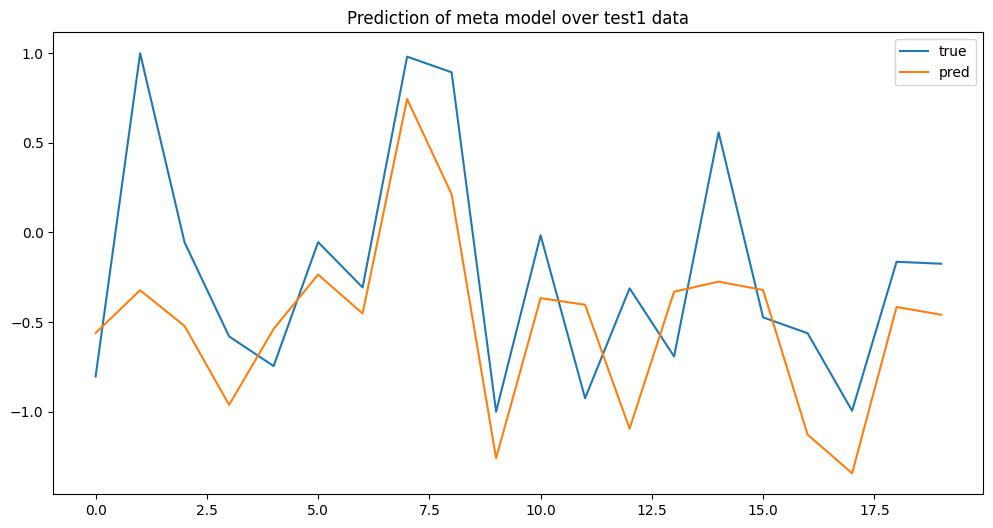

In [292]:
plt.figure(figsize=(12,6))
plt.plot(torch.arange(0,20),test1_y.cpu(),label='true')
plt.plot(torch.arange(0,20),predictions_before.cpu(),label='pred')
plt.title('Prediction of meta model over test1 data')
plt.legend()
plt.show()

In [293]:
## Test of meta model over test 2 data

test_x_before, test_y_before = generate_task2_data()
meta_model.eval()
with torch.no_grad():
    predictions_before = meta_model(test_x_before)
    loss_before = loss_function(predictions_before, test_y_before).item()

print(f"  Loss on test2 before adaptation : {loss_before:.4f}")

  Loss on test2 before adaptation : 1.5677


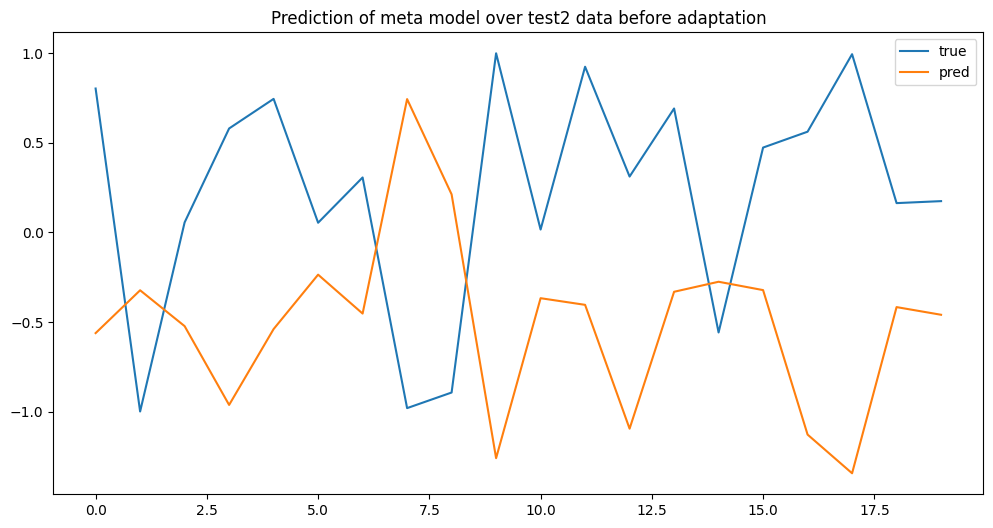

In [294]:
plt.figure(figsize=(12,6))
plt.plot(torch.arange(0,20),test_y_before.cpu(),label='true')
plt.plot(torch.arange(0,20),predictions_before.cpu(),label='pred')
plt.title('Prediction of meta model over test2 data before adaptation')
plt.legend()
plt.show()

In [ ]:
inner_optimizer = optim.SGD(meta_model.parameters(), lr=INNER_LR)

for step in range(1000):    
    train_x, train_y = generate_task2_data()
    inner_optimizer.zero_grad()
    predictions = meta_model(train_x)
    task_loss = loss_function(predictions, train_y)
    task_loss.backward()
    torch.nn.utils.clip_grad_norm_(meta_model.parameters(), max_norm=GRAD_CLIP_NORM)
    inner_optimizer.step()

test_x_after, test_y_after = generate_task2_data()
with torch.no_grad():
    predictions_after = meta_model(test_x_after)
    loss_after = loss_function(predictions_after, test_y_after).item()
print(f"  Loss AFTER adaptation: {loss_after:.4f}")

  Loss AFTER adaptation: 0.0142


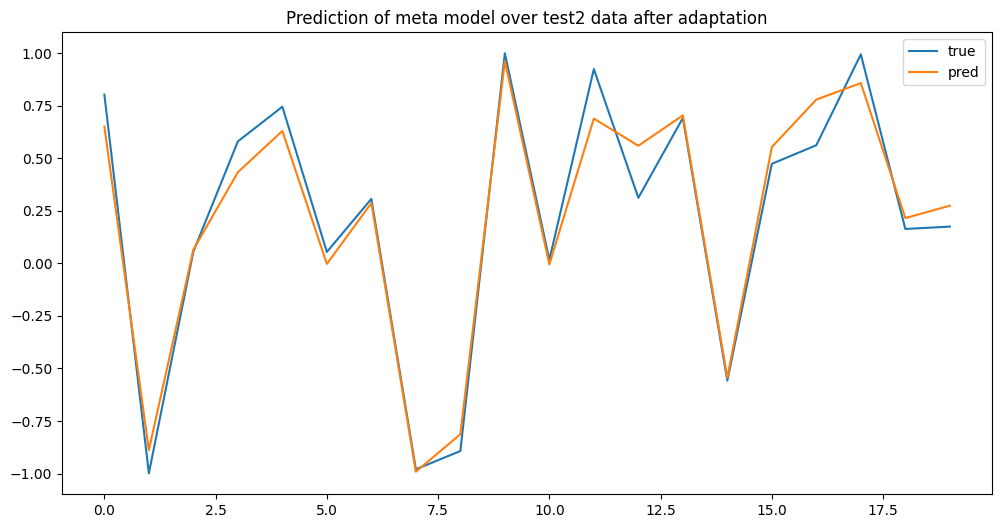

In [302]:
plt.figure(figsize=(12,6))
plt.plot(torch.arange(0,20),test_y_after.cpu(),label='true')
plt.plot(torch.arange(0,20),predictions_after.cpu(),label='pred')
plt.title('Prediction of meta model over test2 data after adaptation')
plt.legend()
plt.show()

In [ ]:
!